In [1]:
# Implementation of a short straddle strategy selling ATM options expiry T = 3 months, no buy backs
# Daily PnL is calculated using capital gains of option premium 

'''
Sell ATM options on days when the portfolio doesn't already have open positions.
Rebalance the portfolio daily based on delta, either buying or short selling the underlying stock.
Calculate daily returns, taking into account the change in option premiums and the profit or loss from rebalancing the underlying stock.
Handle option expiration by checking if the options in the portfolio are expiring on the current day and calculating returns based on whether the options are exercised.
'''

import pandas as pd
import pandas_market_calendars as mcal
import numpy as np
import matplotlib.pyplot as plt
import math as math
from pandas import Timestamp
from equity import find_atm, reverse_option, get_hedge_count


In [2]:
# Load Data
AAPL_options_csv = 'AAPL_Options_22-23.csv'
AAPL_underlying_csv = 'AAPL_Underlying_22-23.csv'
AAPL_options = pd.read_csv(AAPL_options_csv, parse_dates = ["exdate", "date"])
AAPL_underlying = pd.read_csv(AAPL_underlying_csv, parse_dates = ["date"])
find_atm(AAPL_options_csv, AAPL_underlying_csv, pd.Timestamp(2022, 2, 28), 10, 90, 0.5)


[('AAPL 220520C155000', 'AAPL 220520P155000'),
 ('AAPL 220520C160000', 'AAPL 220520P160000'),
 ('AAPL 220520C165000', 'AAPL 220520P165000'),
 ('AAPL 220520P130000', 'AAPL 220520C130000'),
 ('AAPL 220520C185000', 'AAPL 220520P185000'),
 ('AAPL 220520C175000', 'AAPL 220520P175000'),
 ('AAPL 220520P150000', 'AAPL 220520C150000'),
 ('AAPL 220520P145000', 'AAPL 220520C145000'),
 ('AAPL 220520C170000', 'AAPL 220520P170000'),
 ('AAPL 220520C180000', 'AAPL 220520P180000')]

In [7]:
def get_hedge_count(options_df: pd.DataFrame, options_symbols: list[str], date: pd.Timestamp) -> float:
    total_delta = 0
    for symbol in options_symbols:
        option_at_given_time = options_df.loc[(options_df["symbol"] == symbol) & (options_df["date"] == date)]

        if not option_at_given_time.empty:
            delta = option_at_given_time["delta"].iloc[0]
            if not pd.isna(delta):
                total_delta += delta
        else:
            # Handle the case where the option_at_given_time DataFrame is empty
            print(f"No data for {symbol} on {date}")
            continue  # Skip to the next iteration if no data found

    return total_delta

def backtest_short_straddle_with_premium_change(options_df, underlying_df, start_date, end_date):
    portfolio = {'options': [], 'underlying': 0, 'cash': 0}
    daily_returns = []
    previous_cash = 0 # Initialize previous day's cash balance
    nyse_calendar = mcal.get_calendar('NYSE')

    atm_options = find_atm(AAPL_options_csv, AAPL_underlying_csv, start_date, 10, 90, 0.1)
    print(atm_options)
    for call_id, put_id in atm_options:
        call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
        put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
        call_premium = ((call_data['best_bid'] + call_data['best_offer']) / 2) * call_data['contract_size']
        put_premium = ((put_data['best_bid'] + put_data['best_offer']) / 2) * put_data['contract_size']
        portfolio['options'].append({'data': call_data, 'symbol': call_id, 'premium_received': call_premium})
        portfolio['options'].append({'data': put_data, 'symbol': put_id, 'premium_received': put_premium})
        portfolio['cash'] += call_premium + put_premium

    options_df_start_date = options_df[options_df["date"] == start_date]
    expiry_date_list = []
    for option in portfolio["options"]:
        expiry_date_list.append(option["data"]["exdate"])
    expiry_date_set = set(expiry_date_list)
    max_expiry = max(expiry_date_set)
    print(expiry_date_list)
    print(max_expiry)
    print(min(expiry_date_set))

    trading_days = nyse_calendar.schedule(start_date, max_expiry)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            option_data_latest = options_df[options_df["date"] == current_date]
            option_data_latest= option_data_latest[option_data_latest["symbol"] == option["symbol"]]
            # Fetch the option data that is most current as of the current_date
            #option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            exdate = option['data']['exdate']

            if exdate == current_date:
                # Calculate and realize P&L from option expiration
                option_type = option["symbol"].split()[1][6]
                pnl = min(spot_price - (option["data"]["strike_price"]/1000), 0) if 'P' == option_type else min(-spot_price + (option["data"]["strike_price"]/1000), 0)
                pnl *= option["data"]['contract_size']
                contract_size = option["data"]['contract_size']
                portfolio['cash'] += pnl
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = ((option_data_latest['best_bid'].values[0] + option_data_latest['best_offer'].values[0]) / 2) * option["data"]['contract_size']
                daily_unrealized_pnl -= current_premium 

        daily_unrealized_pnl += spot_price * portfolio["underlying"]
        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
        daily_pnl = daily_unrealized_pnl + portfolio["cash"] # Update to include cash change
        daily_pnl += spot_price * portfolio["underlying"]

        contract_size = 100 # TODO: Fix this
        if current_date != trading_day_index:
            delta_without_stocks = get_hedge_count(options_df, portfolio_option_symbols, current_date)
            delta_with_stocks = delta_without_stocks + (portfolio["underlying"] * (1/contract_size))
            portfolio_underlying = 0
            if (abs(delta_with_stocks) > 0.2):
                hedge_count = -int(round(delta_with_stocks * contract_size))
                portfolio["cash"] -= hedge_count * spot_price
                portfolio["underlying"] += hedge_count

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
    
        daily_returns.append(daily_pnl)
        print(portfolio["underlying"])
        print(portfolio["cash"])
        print(daily_unrealized_pnl)
        print("NEW")

    return pd.Series(daily_returns, index=trading_day_index)

# Execute the backtest
daily_returns = backtest_short_straddle_with_premium_change(AAPL_options, AAPL_underlying, AAPL_options['date'].min(), AAPL_options['date'].max())

[('AAPL 220520C155000', 'AAPL 220520P155000'), ('AAPL 220520C160000', 'AAPL 220520P160000'), ('AAPL 220520C165000', 'AAPL 220520P165000'), ('AAPL 220520C175000', 'AAPL 220520P175000'), ('AAPL 220520P150000', 'AAPL 220520C150000'), ('AAPL 220520C170000', 'AAPL 220520P170000'), ('AAPL 220520C180000', 'AAPL 220520P180000')]
[Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00'), Timestamp('2022-05-20 00:00:00')]
2022-05-20 00:00:00
2022-05-20 00:00:00
-30
19811.1
-14857.5
NEW
6
13935.899999999998
-20306.0
NEW
-60
24928.86
-13993.14
NEW
-60
24928.86
-24966.3
NEW
8
13833.300000000001
-25125.199999999997
NEW
84


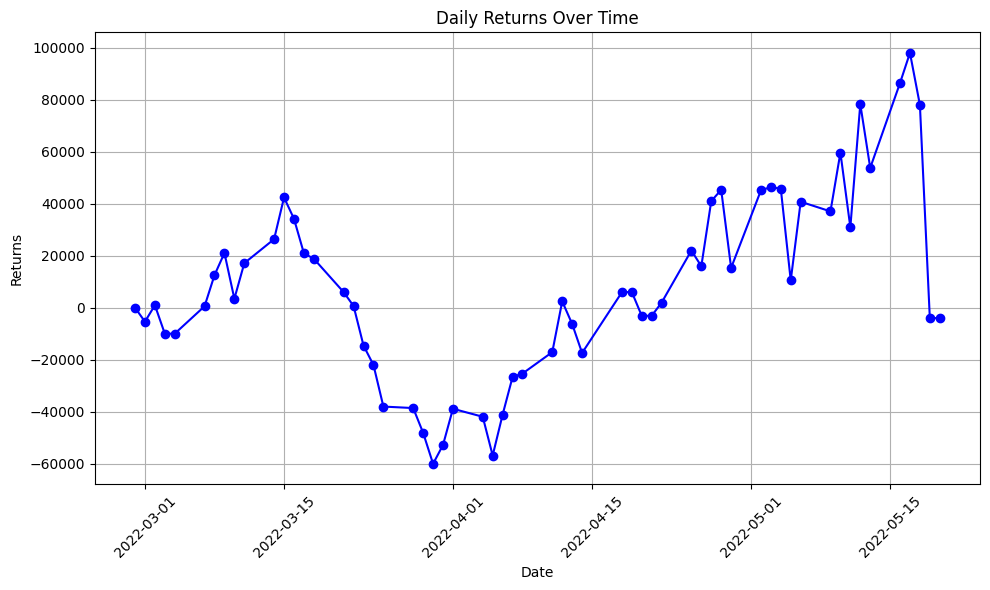

485450.38711000007
2022-02-28        0.00000
2022-03-01    -5390.90000
2022-03-02      942.12000
2022-03-03   -10011.24000
2022-03-04    -9986.54000
2022-03-07      541.10000
2022-03-08    12502.92000
2022-03-09    21031.54000
2022-03-10     3441.22000
2022-03-11    17106.60000
2022-03-14    26350.51000
2022-03-15    42369.35000
2022-03-16    34178.19000
2022-03-17    20898.34000
2022-03-18    18803.80000
2022-03-21     5970.86000
2022-03-22      633.83956
2022-03-23   -14582.72128
2022-03-24   -22032.66162
2022-03-25   -38032.82791
2022-03-28   -38603.89253
2022-03-29   -48125.69292
2022-03-30   -60037.92679
2022-03-31   -52808.41679
2022-04-01   -38879.86679
2022-04-04   -41946.04679
2022-04-05   -56867.72679
2022-04-06   -41142.82679
2022-04-07   -26670.68679
2022-04-08   -25337.28679
2022-04-11   -17090.67679
2022-04-12     2430.18321
2022-04-13    -6274.77525
2022-04-14   -17413.69448
2022-04-18     5891.36350
2022-04-19     6064.80414
2022-04-20    -3091.93671
2022-04-21    -3139

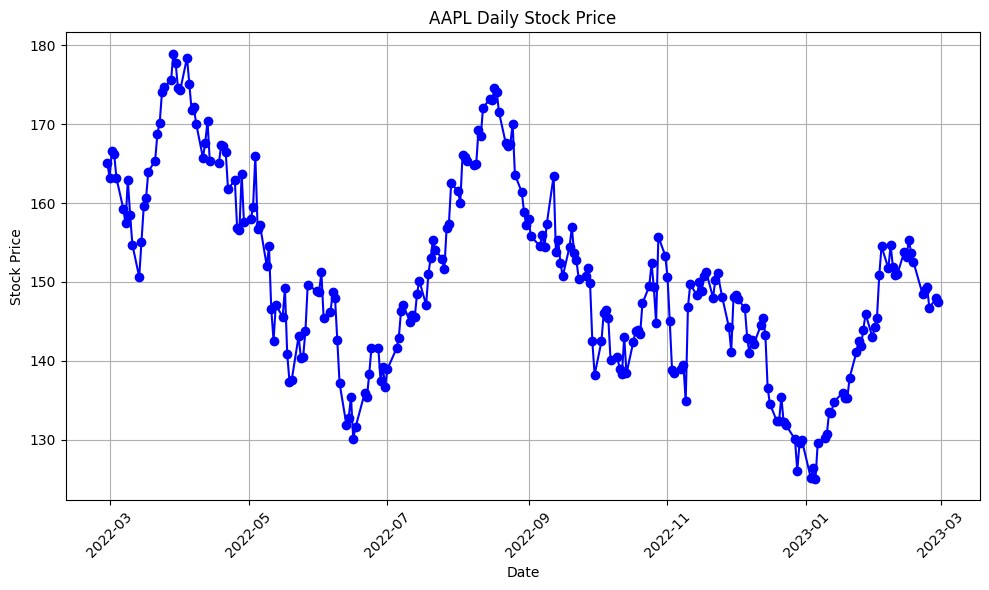

In [5]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns.index, daily_returns.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

total_returns = daily_returns.sum()
print(total_returns)
print(daily_returns)

# Plot daily underlying stock price
plt.figure(figsize=(10, 6))
plt.plot(AAPL_underlying['date'], AAPL_underlying['PRC'], marker='o', linestyle='-', color='b')
plt.title('AAPL Daily Stock Price')
plt.xlabel('Date')
plt.ylabel('Stock Price')
plt.grid(True)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()



In [ ]:
def get_hedge_count(options_df: pd.DataFrame, options_symbols: list[str], date: pd.Timestamp) -> float:
    total_delta = 0
    for symbol in options_symbols:
        option_at_given_time = options_df.loc[(options_df["symbol"] == symbol) & (options_df["date"] == date)]

        if not option_at_given_time.empty:
            delta = option_at_given_time["delta"].iloc[0]
            if not pd.isna(delta):
                total_delta += delta
        else:
            # Handle the case where the option_at_given_time DataFrame is empty
            print(f"No data for {symbol} on {date}")
            continue  # Skip to the next iteration if no data found

    return total_delta

def backtest_short_straddle_with_premium_change(options_df, underlying_df, start_date, end_date):
    portfolio = {'options': [], 'underlying': 0, 'cash': 0}
    daily_returns = []
    previous_cash = 0 # Initialize previous day's cash balance
    nyse_calendar = mcal.get_calendar('NYSE')

    atm_options = find_atm(AAPL_options_csv, AAPL_underlying_csv, start_date, 2, 90, 0.1)
    print(atm_options)
    for call_id, put_id in atm_options:
        call_data = options_df.loc[options_df['symbol'] == call_id].iloc[0]
        put_data = options_df.loc[options_df['symbol'] == put_id].iloc[0]
        call_premium = ((call_data['best_bid'] + call_data['best_offer']) / 2) * call_data['contract_size']
        put_premium = ((put_data['best_bid'] + put_data['best_offer']) / 2) * put_data['contract_size']
        portfolio['options'].append({'data': call_data, 'symbol': call_id, 'premium_received': call_premium})
        portfolio['options'].append({'data': put_data, 'symbol': put_id, 'premium_received': put_premium})
        portfolio['cash'] += call_premium + put_premium

    options_df_start_date = options_df[options_df["date"] == start_date]
    expiry_date_list = []
    for option in portfolio["options"]:
        expiry_date_list.append(option["data"]["exdate"])
    expiry_date_set = set(expiry_date_list)
    max_expiry = max(expiry_date_set)

    trading_days = nyse_calendar.schedule(start_date, max_expiry)
    trading_day_index = mcal.date_range(trading_days, frequency='1D')
    # Change all dates to timestamps, with time 00:00:00
    trading_day_index = [pd.Timestamp(date.date()) for date in trading_day_index]

    for current_date in trading_day_index:
        spot_price = underlying_df.loc[underlying_df['date'] == current_date, 'PRC'].item()
        daily_unrealized_pnl = 0  # Initialize daily unrealized profit/loss from options
        # Process options expiring today
        options_to_remove = []
        for option in portfolio['options']:
            option_data_latest = options_df[options_df["date"] == current_date]
            option_data_latest= option_data_latest[option_data_latest["symbol"] == option["symbol"]]
            # Fetch the option data that is most current as of the current_date
            #option_data_latest = options_df.loc[(options_df['symbol'] == option['symbol']) & (options_df['date'] <= current_date)].sort_values(by='date').iloc[-1]
            exdate = option['data']['exdate']

            if exdate == current_date:
                # Calculate and realize P&L from option expiration
                option_type = option["symbol"].split()[1][6]
                pnl = min(spot_price - (option["data"]["strike_price"]/1000), 0) if 'P' == option_type else min(-spot_price + (option["data"]["strike_price"]/1000), 0)
                pnl *= option["data"]['contract_size']
                contract_size = option["data"]['contract_size']
                portfolio['cash'] += pnl
                options_to_remove.append(option)
            else:
                # Calculate unrealized P&L for non-expiring options using the most recent premium information
                current_premium = ((option_data_latest['best_bid'].values[0] + option_data_latest['best_offer'].values[0]) / 2) * option["data"]['contract_size']
                daily_unrealized_pnl -= current_premium 

        daily_unrealized_pnl += spot_price * portfolio["underlying"]
        # Remove expired options
        for option in options_to_remove:
            portfolio['options'].remove(option)

        # Daily rebalance based on delta
        portfolio_option_symbols = [option['symbol'] for option in portfolio['options']]
        daily_pnl = daily_unrealized_pnl + portfolio["cash"] # Update to include cash change
        daily_pnl += spot_price * portfolio["underlying"]

        contract_size = 100 # TODO: Fix this
        if current_date != trading_day_index:
            delta_without_stocks = get_hedge_count(options_df, portfolio_option_symbols, current_date)
            delta_with_stocks = delta_without_stocks + (portfolio["underlying"] * (1/contract_size))
            portfolio_underlying = 0
            if (abs(delta_with_stocks) > 0.2):
                hedge_count = -int(round(delta_with_stocks * contract_size))
                portfolio["cash"] -= hedge_count * spot_price
                portfolio["underlying"] += hedge_count

        # Add daily unrealized P&L from options to daily returns
        # Calculate and include real cash changes in daily P&L
    
        daily_returns.append(daily_pnl)
        print(portfolio["underlying"])
        print(portfolio["cash"])
        print(daily_unrealized_pnl)
        print("NEW")

    return pd.Series(daily_returns, index=trading_day_index)

# Execute the backtest
daily_returns = backtest_short_straddle_with_premium_change(AAPL_options, AAPL_underlying, AAPL_options['date'].min(), AAPL_options['date'].max())

In [ ]:
# Assuming daily_returns is a pandas Series with a datetime index
plt.figure(figsize=(10, 6))  # Set the figure size
plt.plot(daily_returns.index, daily_returns.values, marker='o', linestyle='-', color='b')  # Plot daily returns
plt.title('Daily Returns Over Time')  # Set title
plt.xlabel('Date')  # Set x-axis label
plt.ylabel('Returns')  # Set y-axis label
plt.grid(True)  # Show grid
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()  # Display the plot

total_returns = daily_returns.sum()
print(total_returns)
print(daily_returns)